<h3>DATA COLLECTION</h3>

In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv('Mobile Reviews Sentiment null.csv', encoding='latin1')

In [3]:
df.head()

,review_id,customer_name,age,brand,model,price_usd,price_local,currency,exchange_rate_to_usd,rating,...,language,review_date,verified_purchase,battery_life_rating,camera_rating,performance_rating,design_rating,display_rating,helpful_votes,source
0,1,Aryan Maharaj,45,Realme,Realme 12 Pro,337.31,â¹27996.73,INR,83.00,2.0,...,Hindi,11/6/2023,True,1,1,3,2,1,1,Amazon
1,2,Davi Miguel Sousa,18,Realme,Realme 12 Pro,307.78,R$1754.35,BRL,5.70,4.0,...,Portuguese,3/30/2023,True,3,2,4,3,2,5,Flipkart
2,3,Pahal Balay,27,Google,Pixel 6,864.53,â¹71755.99,INR,83.00,4.0,...,Hindi,12/7/2022,True,3,5,3,2,4,8,AliExpress
3,4,David Guzman,19,Xiaomi,Redmi Note 13,660.94,Ø¯.Ø¥2425.65,AED,3.67,3.0,...,English,3/11/2025,False,1,3,2,1,2,3,Amazon
4,5,Yago LeÃ£o,38,Motorola,Edge 50,792.13,R$4515.14,BRL,5.70,3.0,...,Portuguese,9/29/2023,True,3,3,2,2,1,0,BestBuy


In [4]:
df.shape

(50000, 22)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   review_id             50000 non-null  int64  
 1   customer_name         50000 non-null  object 
 2   age                   50000 non-null  int64  
 3   brand                 50000 non-null  object 
 4   model                 50000 non-null  object 
 5   price_usd             47550 non-null  float64
 6   price_local           47569 non-null  object 
 7   currency              50000 non-null  object 
 8   exchange_rate_to_usd  50000 non-null  float64
 9   rating                47547 non-null  float64
 10  sentiment             47555 non-null  object 
 11  country               50000 non-null  object 
 12  language              50000 non-null  object 
 13  review_date           50000 non-null  object 
 14  verified_purchase     50000 non-null  bool   
 15  battery_life_rating

In [6]:
df.describe()

,review_id,age,price_usd,exchange_rate_to_usd,rating,battery_life_rating,camera_rating,performance_rating,design_rating,display_rating,helpful_votes
count,50000.000000,50000.000000,47550.00000,50000.000000,47547.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,25000.500000,30.075220,689.89277,12.057946,3.123415,2.71800,2.717640,2.719620,2.713960,2.721280,3.644180
std,14433.901067,8.931307,310.32722,26.553332,1.249067,1.34827,1.345001,1.349208,1.343346,1.352121,2.432745
min,1.000000,18.000000,180.02000,0.780000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,0.000000
25%,12500.750000,23.000000,450.75500,1.000000,2.000000,1.00000,1.000000,1.000000,1.000000,1.000000,2.000000
50%,25000.500000,29.000000,637.58500,1.530000,3.000000,3.00000,3.000000,3.000000,3.000000,3.000000,3.000000
75%,37500.250000,36.000000,901.45750,5.700000,4.000000,4.00000,4.000000,4.000000,4.000000,4.000000,5.000000
max,50000.000000,65.000000,1499.89000,83.000000,5.000000,5.00000,5.000000,5.000000,5.000000,5.000000,17.000000


<H3>DATA PREPROCESSING</H3>

In [7]:
df.groupby('model')['price_usd'].median()

model
Edge 50             514.920
Galaxy A55          908.740
Galaxy Note 20      905.775
Galaxy S24          888.435
Galaxy Z Flip       905.380
Mi 13 Pro           443.830
Moto G Power        505.340
OnePlus 11R         667.025
OnePlus 12          668.090
OnePlus Nord 3      669.400
Pixel 6             808.530
Pixel 7a            809.440
Pixel 8             799.520
Poco X6             451.600
Razr 40             511.440
Realme 12 Pro       396.410
Realme Narzo 70     392.820
Redmi Note 13       450.800
iPhone 13          1106.380
iPhone 14          1094.510
iPhone 15 Pro      1102.270
iPhone SE          1101.030
Name: price_usd, dtype: float64

In [8]:
df['price_usd'].isnull().sum()

np.int64(2450)

In [9]:
df['price_usd'] = df.groupby('model')['price_usd'].transform(lambda x : x.fillna(x.median()))

In [10]:
df['price_usd'].isnull().sum()

np.int64(0)

In [11]:
df.groupby('model')['rating'].mean()

model
Edge 50            3.092576
Galaxy A55         3.092765
Galaxy Note 20     3.150789
Galaxy S24         3.075314
Galaxy Z Flip      3.134887
Mi 13 Pro          3.098368
Moto G Power       3.128399
OnePlus 11R        3.117369
OnePlus 12         3.135601
OnePlus Nord 3     3.143046
Pixel 6            3.119037
Pixel 7a           3.126015
Pixel 8            3.129132
Poco X6            3.126138
Razr 40            3.108497
Realme 12 Pro      3.147565
Realme Narzo 70    3.126423
Redmi Note 13      3.119727
iPhone 13          3.158239
iPhone 14          3.185731
iPhone 15 Pro      3.083924
iPhone SE          3.101814
Name: rating, dtype: float64

In [12]:
df['rating'].isnull().sum()

np.int64(2453)

In [13]:
df['rating'] = df.groupby('model')['rating'].transform(lambda x : x.fillna(x.median()))

In [14]:
df['rating'].isnull().sum()

np.int64(0)

In [15]:
df['sentiment'].unique()

array(['Negative', 'Positive', 'Neutral', nan], dtype=object)

In [16]:
df['sentiment'].isnull().sum()

np.int64(2445)

In [17]:
df['sentiment'] = df['sentiment'].fillna('Unknown')

In [18]:
df['sentiment'].isnull().sum()

np.int64(0)

In [19]:
df['source'].unique()

array(['Amazon', 'Flipkart', 'AliExpress', 'BestBuy', 'eBay', nan],
      dtype=object)

In [20]:
df['source'].isnull().sum()

np.int64(2448)

In [21]:
df['source'] = df['source'].fillna('Unknown')

In [22]:
df['source'].isnull().sum()

np.int64(0)

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   review_id             50000 non-null  int64  
 1   customer_name         50000 non-null  object 
 2   age                   50000 non-null  int64  
 3   brand                 50000 non-null  object 
 4   model                 50000 non-null  object 
 5   price_usd             50000 non-null  float64
 6   price_local           47569 non-null  object 
 7   currency              50000 non-null  object 
 8   exchange_rate_to_usd  50000 non-null  float64
 9   rating                50000 non-null  float64
 10  sentiment             50000 non-null  object 
 11  country               50000 non-null  object 
 12  language              50000 non-null  object 
 13  review_date           50000 non-null  object 
 14  verified_purchase     50000 non-null  bool   
 15  battery_life_rating

<h4>All the null values has been handled effectively</h4>

In [24]:
df.duplicated().sum()

np.int64(0)

In [25]:
df.describe()

,review_id,age,price_usd,exchange_rate_to_usd,rating,battery_life_rating,camera_rating,performance_rating,design_rating,display_rating,helpful_votes
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,25000.500000,30.075220,689.795238,12.057946,3.117360,2.71800,2.717640,2.719620,2.713960,2.721280,3.644180
std,14433.901067,8.931307,307.305506,26.553332,1.218333,1.34827,1.345001,1.349208,1.343346,1.352121,2.432745
min,1.000000,18.000000,180.020000,0.780000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,0.000000
25%,12500.750000,23.000000,450.800000,1.000000,2.000000,1.00000,1.000000,1.000000,1.000000,1.000000,2.000000
50%,25000.500000,29.000000,640.805000,1.530000,3.000000,3.00000,3.000000,3.000000,3.000000,3.000000,3.000000
75%,37500.250000,36.000000,901.405000,5.700000,4.000000,4.00000,4.000000,4.000000,4.000000,4.000000,5.000000
max,50000.000000,65.000000,1499.890000,83.000000,5.000000,5.00000,5.000000,5.000000,5.000000,5.000000,17.000000


In [26]:
base_drop = ['review_id', 'customer_name', 'price_local', 'currency', 
             'exchange_rate_to_usd', 'review_date', 'language']
df = df.drop(columns=base_drop)

In [27]:
df.shape

(50000, 15)

In [28]:
df['verified_purchase'] = df['verified_purchase'].astype(int)

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  50000 non-null  int64  
 1   brand                50000 non-null  object 
 2   model                50000 non-null  object 
 3   price_usd            50000 non-null  float64
 4   rating               50000 non-null  float64
 5   sentiment            50000 non-null  object 
 6   country              50000 non-null  object 
 7   verified_purchase    50000 non-null  int64  
 8   battery_life_rating  50000 non-null  int64  
 9   camera_rating        50000 non-null  int64  
 10  performance_rating   50000 non-null  int64  
 11  design_rating        50000 non-null  int64  
 12  display_rating       50000 non-null  int64  
 13  helpful_votes        50000 non-null  int64  
 14  source               50000 non-null  object 
dtypes: float64(2), int64(8), object(5)
m

In [30]:
df['rating'] = df['rating'].astype(int)

In [31]:
df['brand'].unique()

array(['Realme', 'Google', 'Xiaomi', 'Motorola', 'Apple', 'OnePlus',
       'Samsung'], dtype=object)

In [32]:
df['country'].unique()

array(['India', 'Brazil', 'UAE', 'Australia', 'Germany', 'UK', 'Canada',
       'USA'], dtype=object)

In [33]:
# The 4 categorical columns you want to encode
categorical_cols = ['model','brand', 'sentiment', 'country', 'source']

df = pd.get_dummies(
    df, 
    columns=categorical_cols, 
    prefix='', 
    prefix_sep='', 
    dtype=int
)

In [34]:
df.head()

,age,price_usd,rating,verified_purchase,battery_life_rating,camera_rating,performance_rating,design_rating,display_rating,helpful_votes,...,India,UAE,UK,USA,AliExpress,Amazon,BestBuy,Flipkart,Unknown,eBay
0,45,337.31,2,1,1,1,3,2,1,1,...,1,0,0,0,0,1,0,0,0,0
1,18,307.78,4,1,3,2,4,3,2,5,...,0,0,0,0,0,0,0,1,0,0
2,27,864.53,4,1,3,5,3,2,4,8,...,1,0,0,0,1,0,0,0,0,0
3,19,660.94,3,0,1,3,2,1,2,3,...,0,1,0,0,0,1,0,0,0,0
4,38,792.13,3,1,3,3,2,2,1,0,...,0,0,0,0,0,0,1,0,0,0


In [35]:
df.columns

Index(['age', 'price_usd', 'rating', 'verified_purchase',
       'battery_life_rating', 'camera_rating', 'performance_rating',
       'design_rating', 'display_rating', 'helpful_votes', 'Edge 50',
       'Galaxy A55', 'Galaxy Note 20', 'Galaxy S24', 'Galaxy Z Flip',
       'Mi 13 Pro', 'Moto G Power', 'OnePlus 11R', 'OnePlus 12',
       'OnePlus Nord 3', 'Pixel 6', 'Pixel 7a', 'Pixel 8', 'Poco X6',
       'Razr 40', 'Realme 12 Pro', 'Realme Narzo 70', 'Redmi Note 13',
       'iPhone 13', 'iPhone 14', 'iPhone 15 Pro', 'iPhone SE', 'Apple',
       'Google', 'Motorola', 'OnePlus', 'Realme', 'Samsung', 'Xiaomi',
       'Negative', 'Neutral', 'Positive', 'Unknown', 'Australia', 'Brazil',
       'Canada', 'Germany', 'India', 'UAE', 'UK', 'USA', 'AliExpress',
       'Amazon', 'BestBuy', 'Flipkart', 'Unknown', 'eBay'],
      dtype='object')

In [36]:
df=df.drop(columns = 'age')

In [37]:
df.columns

Index(['price_usd', 'rating', 'verified_purchase', 'battery_life_rating',
       'camera_rating', 'performance_rating', 'design_rating',
       'display_rating', 'helpful_votes', 'Edge 50', 'Galaxy A55',
       'Galaxy Note 20', 'Galaxy S24', 'Galaxy Z Flip', 'Mi 13 Pro',
       'Moto G Power', 'OnePlus 11R', 'OnePlus 12', 'OnePlus Nord 3',
       'Pixel 6', 'Pixel 7a', 'Pixel 8', 'Poco X6', 'Razr 40', 'Realme 12 Pro',
       'Realme Narzo 70', 'Redmi Note 13', 'iPhone 13', 'iPhone 14',
       'iPhone 15 Pro', 'iPhone SE', 'Apple', 'Google', 'Motorola', 'OnePlus',
       'Realme', 'Samsung', 'Xiaomi', 'Negative', 'Neutral', 'Positive',
       'Unknown', 'Australia', 'Brazil', 'Canada', 'Germany', 'India', 'UAE',
       'UK', 'USA', 'AliExpress', 'Amazon', 'BestBuy', 'Flipkart', 'Unknown',
       'eBay'],
      dtype='object')

In [38]:
df

,price_usd,rating,verified_purchase,battery_life_rating,camera_rating,performance_rating,design_rating,display_rating,helpful_votes,Edge 50,...,India,UAE,UK,USA,AliExpress,Amazon,BestBuy,Flipkart,Unknown,eBay
0,337.31,2,1,1,1,3,2,1,1,0,...,1,0,0,0,0,1,0,0,0,0
1,307.78,4,1,3,2,4,3,2,5,0,...,0,0,0,0,0,0,0,1,0,0
2,864.53,4,1,3,5,3,2,4,8,0,...,1,0,0,0,1,0,0,0,0,0
3,660.94,3,0,1,3,2,1,2,3,0,...,0,1,0,0,0,1,0,0,0,0
4,792.13,3,1,3,3,2,2,1,0,1,...,0,0,0,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,526.10,4,0,3,3,4,3,5,4,0,...,0,0,0,0,0,0,1,0,0,0
49996,911.85,3,0,3,2,4,1,3,2,0,...,0,0,0,0,1,0,0,0,0,0
49997,1155.32,3,1,2,3,4,4,5,4,0,...,0,1,0,0,0,1,0,0,0,0
49998,459.04,3,1,1,2,2,1,3,6,0,...,0,0,0,1,0,0,0,0,1,0


In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 56 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   price_usd            50000 non-null  float64
 1   rating               50000 non-null  int64  
 2   verified_purchase    50000 non-null  int64  
 3   battery_life_rating  50000 non-null  int64  
 4   camera_rating        50000 non-null  int64  
 5   performance_rating   50000 non-null  int64  
 6   design_rating        50000 non-null  int64  
 7   display_rating       50000 non-null  int64  
 8   helpful_votes        50000 non-null  int64  
 9   Edge 50              50000 non-null  int64  
 10  Galaxy A55           50000 non-null  int64  
 11  Galaxy Note 20       50000 non-null  int64  
 12  Galaxy S24           50000 non-null  int64  
 13  Galaxy Z Flip        50000 non-null  int64  
 14  Mi 13 Pro            50000 non-null  int64  
 15  Moto G Power         50000 non-null 

In [40]:
from sklearn.preprocessing import StandardScaler

# 1. Initialize the Standard Scaler
scaler = StandardScaler()

# 2. Scale all the numeric features
df_scaled_array = scaler.fit_transform(df)

# 3. Convert it back into a clean DataFrame with the original column names
df_scaled = pd.DataFrame(df_scaled_array, columns=df.columns)

In [41]:
df_scaled

,price_usd,rating,verified_purchase,battery_life_rating,camera_rating,performance_rating,design_rating,display_rating,helpful_votes,Edge 50,...,India,UAE,UK,USA,AliExpress,Amazon,BestBuy,Flipkart,Unknown,eBay
0,-1.147030,-0.917131,0.497812,-1.274238,-1.277067,0.207813,-0.531484,-1.273035,-1.086923,-0.220336,...,2.676677,-0.378345,-0.376581,-0.384331,-0.485297,2.062999,-0.482874,-0.483724,-0.226893,-0.486618
1,-1.243125,0.724472,0.497812,0.209159,-0.533566,0.948996,0.212933,-0.533449,0.557327,-0.220336,...,-0.373598,-0.378345,-0.376581,-0.384331,-0.485297,-0.484731,-0.482874,2.067294,-0.226893,-0.486618
2,0.568608,0.724472,0.497812,0.209159,1.696937,0.207813,-0.531484,0.945723,1.790513,-0.220336,...,2.676677,-0.378345,-0.376581,-0.384331,2.060592,-0.484731,-0.482874,-0.483724,-0.226893,-0.486618
3,-0.093899,-0.096329,-2.008792,-1.274238,0.209935,-0.533370,-1.275902,-0.533449,-0.264798,-0.220336,...,-0.373598,2.643094,-0.376581,-0.384331,-0.485297,2.062999,-0.482874,-0.483724,-0.226893,-0.486618
4,0.333010,-0.096329,0.497812,0.209159,0.209935,-0.533370,-0.531484,-1.273035,-1.497985,4.538532,...,-0.373598,-0.378345,-0.376581,-0.384331,-0.485297,-0.484731,2.070934,-0.483724,-0.226893,-0.486618
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,-0.532684,0.724472,-2.008792,0.209159,0.209935,0.948996,0.212933,1.685310,0.146264,-0.220336,...,-0.373598,-0.378345,-0.376581,-0.384331,-0.485297,-0.484731,2.070934,-0.483724,-0.226893,-0.486618
49996,0.722594,-0.096329,-2.008792,0.209159,-0.533566,0.948996,-1.275902,0.206137,-0.675860,-0.220336,...,-0.373598,-0.378345,-0.376581,-0.384331,2.060592,-0.484731,-0.482874,-0.483724,-0.226893,-0.486618
49997,1.514875,-0.096329,0.497812,-0.532540,0.209935,0.948996,0.957351,1.685310,0.146264,-0.220336,...,-0.373598,2.643094,-0.376581,-0.384331,-0.485297,2.062999,-0.482874,-0.483724,-0.226893,-0.486618
49998,-0.750906,-0.096329,0.497812,-1.274238,-0.533566,-0.533370,-1.275902,0.206137,0.968389,-0.220336,...,-0.373598,-0.378345,-0.376581,2.601924,-0.485297,-0.484731,-0.482874,-0.483724,4.407362,-0.486618


In [52]:
df_scaled.to_csv('Scaled_data.csv', index =False)

<h3>EXPLORATORY DATA ANALYSIS</h3>

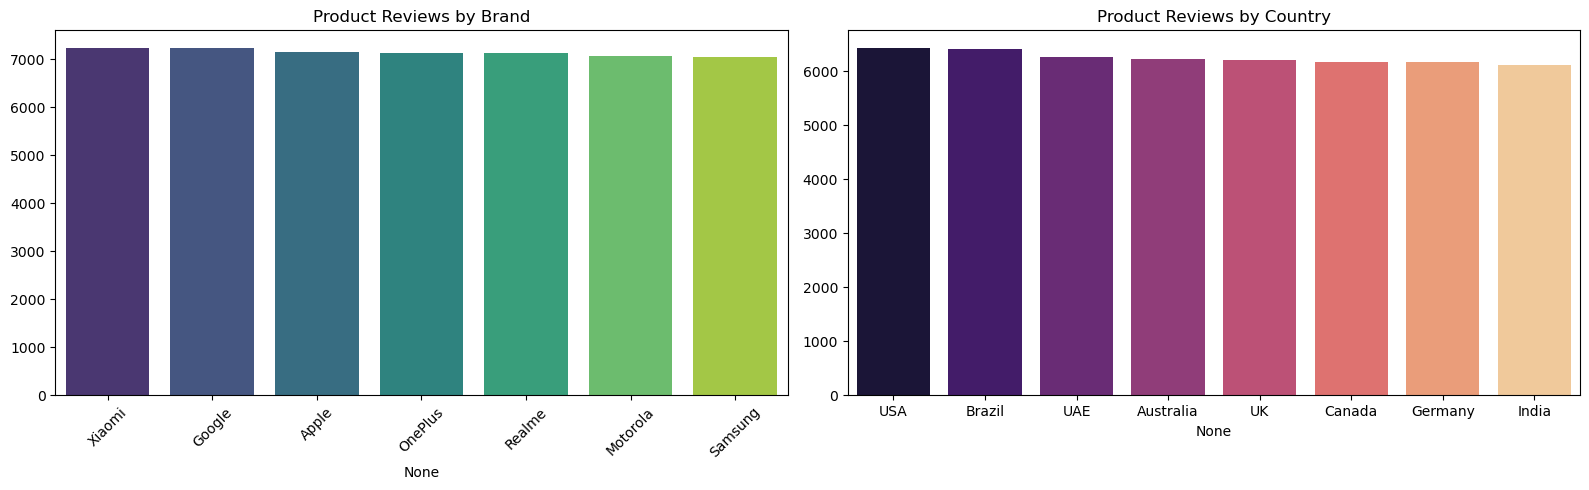

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns

# Brands list from  dataframe
brands = ['Apple', 'Google', 'Motorola', 'OnePlus', 'Realme', 'Samsung', 'Xiaomi']
brand_counts = df[brands].sum().sort_values(ascending=False)

# Countries list from  dataframe
countries = ['Australia', 'Brazil', 'Canada', 'Germany', 'India', 'UAE', 'UK', 'USA']
country_counts = df[countries].sum().sort_values(ascending=False)

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Fixed Brand Barplot
sns.barplot(
    x=brand_counts.index, 
    y=brand_counts.values, 
    ax=axes[0], 
    palette='viridis',
    hue=brand_counts.index,
    legend=False
)
axes[0].set_title('Product Reviews by Brand')
axes[0].tick_params(axis='x', rotation=45)

# Fixed Country Barplot
sns.barplot(
    x=country_counts.index, 
    y=country_counts.values, 
    ax=axes[1], 
    palette='magma',
    hue=country_counts.index,
    legend=False
)
axes[1].set_title('Product Reviews by Country')

plt.tight_layout()
plt.show()

In [46]:
# List out all individual phone models columns present in the data
models = [
    'Edge 50', 'Galaxy A55', 'Galaxy Note 20', 'Galaxy S24', 'Galaxy Z Flip', 
    'Mi 13 Pro', 'Moto G Power', 'OnePlus 11R', 'OnePlus 12', 'OnePlus Nord 3', 
    'Pixel 6', 'Pixel 7a', 'Pixel 8', 'Poco X6', 'Razr 40', 'Realme 12 Pro', 
    'Realme Narzo 70', 'Redmi Note 13', 'iPhone 13', 'iPhone 14', 'iPhone 15 Pro', 'iPhone SE'
]

# Calculate mean rating for each model
model_avg_ratings = {}
for m in models:
    # Average rating where the phone model column == 1
    model_avg_ratings[m] = df[df[m] == 1]['rating'].mean()

model_ratings_series = pd.Series(model_avg_ratings).sort_values(ascending=False)

print("--- TOP 5 HIGHEST RATED PRODUCTS ---")
print(model_ratings_series.head(5))

print("\n--- BOTTOM 5 LOWEST RATED PRODUCTS ---")
print(model_ratings_series.tail(5))

--- TOP 5 HIGHEST RATED PRODUCTS ---
iPhone 14         3.176174
iPhone 13         3.150538
Galaxy Note 20    3.144215
Realme 12 Pro     3.140594
OnePlus Nord 3    3.136555
dtype: float64

--- BOTTOM 5 LOWEST RATED PRODUCTS ---
Mi 13 Pro        3.093661
Galaxy A55       3.088926
Edge 50          3.087257
iPhone 15 Pro    3.079197
Galaxy S24       3.071550
dtype: float64


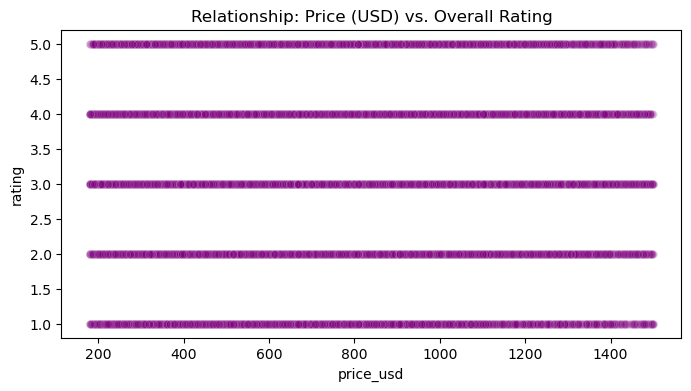

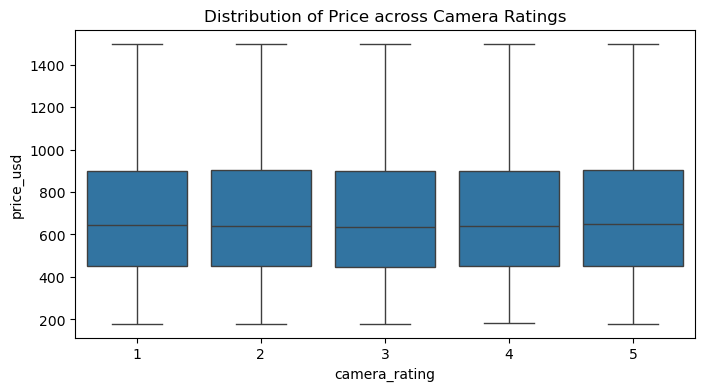

In [47]:
# Scatter plot between Price and Overall Rating
plt.figure(figsize=(8, 4))
sns.scatterplot(data=df, x='price_usd', y='rating', alpha=0.1, color='purple')
plt.title('Relationship: Price (USD) vs. Overall Rating')
plt.show()

# Boxplot showing how sub-ratings look across prices
plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x='camera_rating', y='price_usd')
plt.title('Distribution of Price across Camera Ratings')
plt.show()

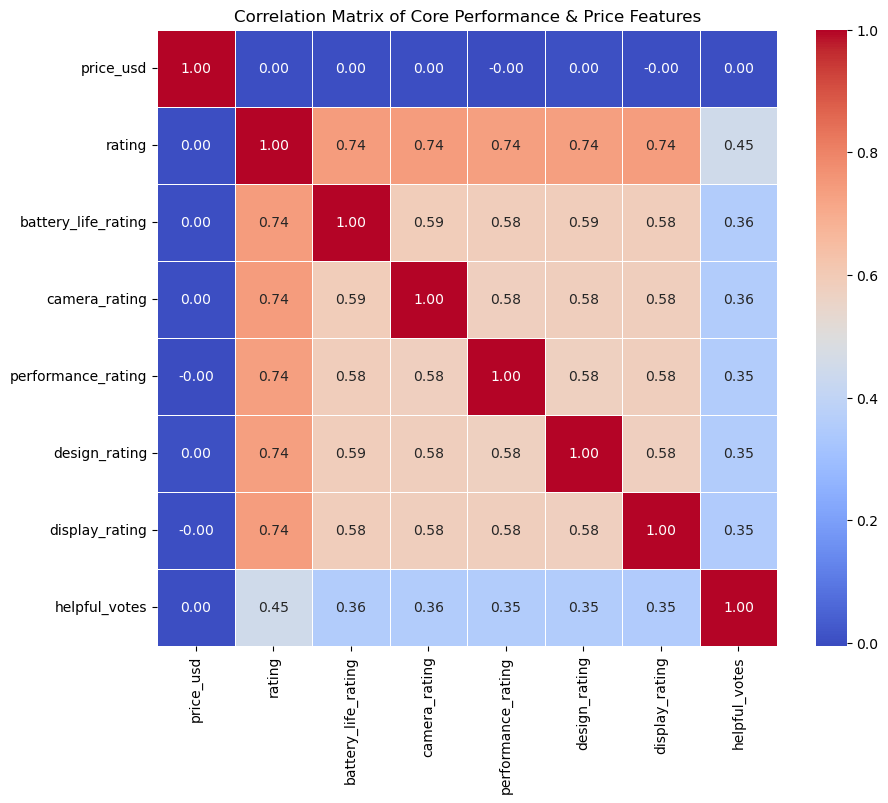

In [48]:
plt.figure(figsize=(10, 8))
core_numeric = ['price_usd', 'rating', 'battery_life_rating', 'camera_rating', 
                'performance_rating', 'design_rating', 'display_rating', 'helpful_votes']

corr_matrix = df[core_numeric].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of Core Performance & Price Features')
plt.show()

In [50]:
new_columns = []
unknown_count = 0

for col in df.columns:
    if col == 'Unknown':
        unknown_count += 1
        if unknown_count == 2:
            new_columns.append('Unknown_Source')
        else:
            new_columns.append(col)
    else:
        new_columns.append(col)

df.columns = new_columns

In [51]:
sentiments = ['Positive', 'Negative', 'Neutral', 'Unknown']

for s in sentiments:
    print(f"\n=== Summary Statistics for {s} Sentiment Reviews ===")
    subset = df[df[s] == 1]
    print(subset[['price_usd', 'rating', 'performance_rating']].describe().loc[['mean', 'std', 'min', 'max']])


=== Summary Statistics for Positive Sentiment Reviews ===
        price_usd    rating  performance_rating
mean   689.977413  3.911460            3.414771
std    307.708872  0.804438            1.174115
min    180.070000  1.000000            1.000000
max   1499.890000  5.000000            5.000000

=== Summary Statistics for Negative Sentiment Reviews ===
        price_usd    rating  performance_rating
mean   690.964313  1.679619            1.527510
std    309.370603  0.737316            0.810515
min    180.330000  1.000000            1.000000
max   1499.650000  4.000000            5.000000

=== Summary Statistics for Neutral Sentiment Reviews ===
        price_usd    rating  performance_rating
mean   688.832988  2.511692            2.140977
std    304.764332  0.826891            1.094713
min    180.020000  1.000000            1.000000
max   1499.820000  5.000000            5.000000

=== Summary Statistics for Unknown Sentiment Reviews ===
        price_usd    rating  performance_ratin

In [53]:
df.to_csv('Cleaned_data.csv',index = False)